# Ensemble Methods

Ensemble learning methods aggregate the predictions of multiple base learners to form a single, more robust model. This project explores three core concepts: Hard Voting, Bagging (and Random Forests), and Boosting (AdaBoost & Gradient Boosting).

### Hard Voting Classifier
A Voting Classifier is the simplest ensemble. It trains several different models (e.g., Logistic Regression, SVM, and Random Forest) and predicts the class that gets the most "votes" from the individual models.

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from mlxtend.plotting import plot_decision_regions

# Load and clean Palmer Penguins dataset from kaggle
df = sns.load_dataset("penguins").dropna()
# We will classify Adelie (0) vs Gentoo (1)
df = df[df['species'].isin(['Adelie', 'Gentoo'])]
X = df[['bill_length_mm', 'flipper_length_mm']].values
y = df['species'].map({'Adelie': 0, 'Gentoo': 1}).values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# Standardize for models like SVM/Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize diverse classifiers
log_clf = LogisticRegression()
rnd_clf = RandomForestClassifier(n_estimators=100)
svm_clf = SVC(probability=True)

voting_clf = VotingClassifier(
    estimators=[('lr', log_clf), ('rf', rnd_clf), ('svc', svm_clf)],
    voting='hard'
)

# Comparison of individual vs. ensemble
for clf in (log_clf, rnd_clf, svm_clf, voting_clf):
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    print(f"{clf.__class__.__name__} Accuracy: {accuracy_score(y_test, y_pred):.3f}")

LogisticRegression Accuracy: 1.000
RandomForestClassifier Accuracy: 0.991
SVC Accuracy: 1.000
VotingClassifier Accuracy: 1.000


### Bagging and Random Forests
 Bagging (Bootstrap Aggregating) involves training multiple models on different random subsets of the data (with replacement). Random Forests take this further by also selecting a random subset of features for each split.

Comparison: Decision Stump vs. Bagging vs. Forest

We will compare a decision stump with max_depth=1 against ensemble versions.

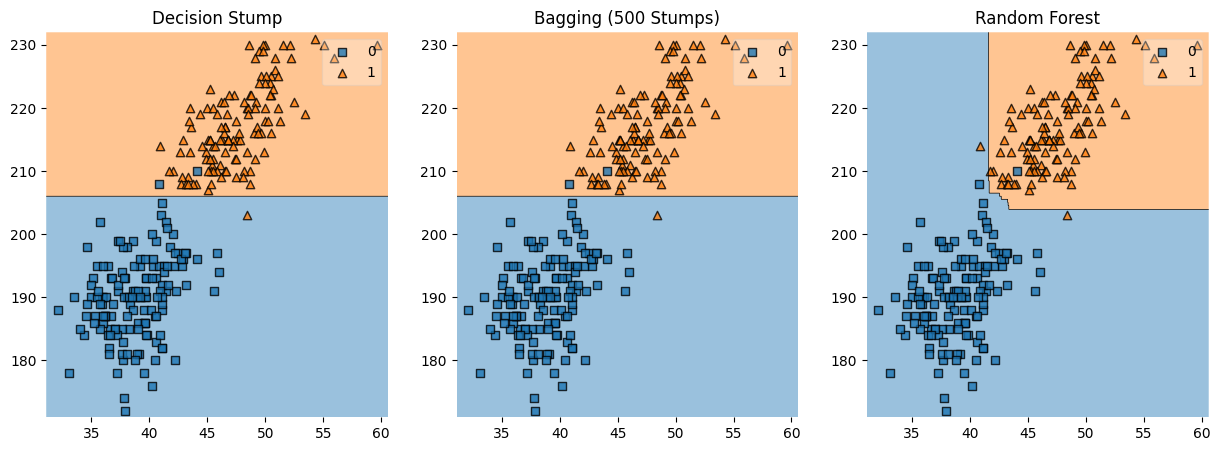

Bagging Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99        59
           1       1.00      0.98      0.99        47

    accuracy                           0.99       106
   macro avg       0.99      0.99      0.99       106
weighted avg       0.99      0.99      0.99       106

Forest Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99        59
           1       1.00      0.98      0.99        47

    accuracy                           0.99       106
   macro avg       0.99      0.99      0.99       106
weighted avg       0.99      0.99      0.99       106



In [7]:
# Single Decision Stump
stump_clf = DecisionTreeClassifier(max_depth=1, random_state=42)
stump_clf.fit(X_train, y_train)

# Bagging with ~500 Stumps
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=500, bootstrap=True, n_jobs=-1, random_state=42
)
bag_clf.fit(X_train, y_train)

# Random Forest (Max Depth 1)
forest_clf = RandomForestClassifier(n_estimators=500, max_depth=1, n_jobs=-1, random_state=42)
forest_clf.fit(X_train, y_train)

# Visualizing Decision Boundaries
plt.figure(figsize=(15, 5))
titles = ["Decision Stump", "Bagging (500 Stumps)", "Random Forest"]
for i, clf in enumerate([stump_clf, bag_clf, forest_clf]):
    plt.subplot(1, 3, i+1)
    plot_decision_regions(X, y, clf=clf)
    plt.title(titles[i])
plt.show()

print("Bagging Report:\n", classification_report(y_test, bag_clf.predict(X_test)))
print("Forest Report:\n", classification_report(y_test, forest_clf.predict(X_test)))

A key advantage of Random Forests is identifying which features drive the classification.

In [8]:
# Re-training with more features to see importance
X_multi = df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].values
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y, test_size=0.4, random_state=42)

forest_clf.fit(X_train_m, y_train_m)
feature_names = ['bill_length', 'bill_depth', 'flipper_length', 'body_mass']
for name, score in zip(feature_names, forest_clf.feature_importances_):
    print(f"Feature: {name:15} Importance: {score:.4f}")

Feature: bill_length     Importance: 0.1800
Feature: bill_depth      Importance: 0.3380
Feature: flipper_length  Importance: 0.4720
Feature: body_mass       Importance: 0.0100


In [9]:
print("--- Random Forest Feature Importance ---")
names = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
for name, score in zip(names, forest_clf.feature_importances_):
    print(f"{name}: {score:.4f}")
print("\n")

--- Random Forest Feature Importance ---
bill_length_mm: 0.1800
bill_depth_mm: 0.3380
flipper_length_mm: 0.4720
body_mass_g: 0.0100




### Boosting (AdaBoost and Gradient Boosting)

Boosting trains models sequentially. Each new model attempts to fix the errors of the previous one.

AdaBoost:

AdaBoost focuses on misclassified points by increasing their weights for the next iteration.

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


--- AdaBoost Classification Report ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        59
           1       1.00      0.96      0.98        47

    accuracy                           0.98       106
   macro avg       0.98      0.98      0.98       106
weighted avg       0.98      0.98      0.98       106





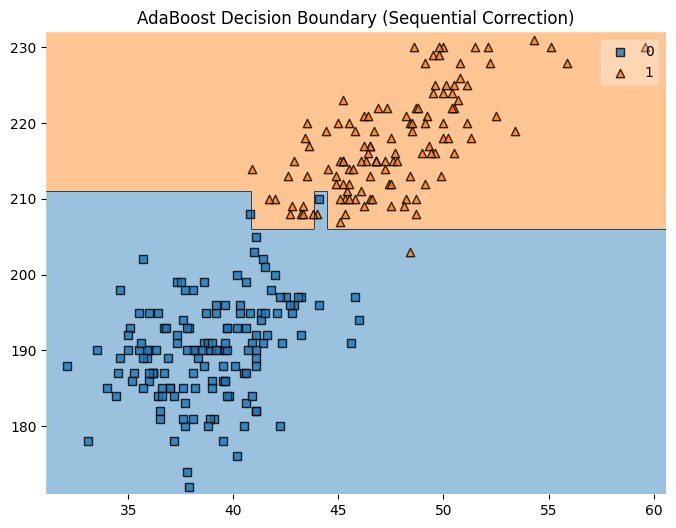

In [10]:
# AdaBoost with Decision Stumps
ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=50, learning_rate=0.5, algorithm="SAMME"
)
ada_clf.fit(X_train, y_train)

ada_y_pred = ada_clf.predict(X_test)
print("--- AdaBoost Classification Report ---")
print(classification_report(y_test, ada_y_pred))
print("\n")
plt.figure(figsize=(8, 6))
plot_decision_regions(X, y, clf=ada_clf)
plt.title("AdaBoost Decision Boundary (Sequential Correction)")
plt.show()

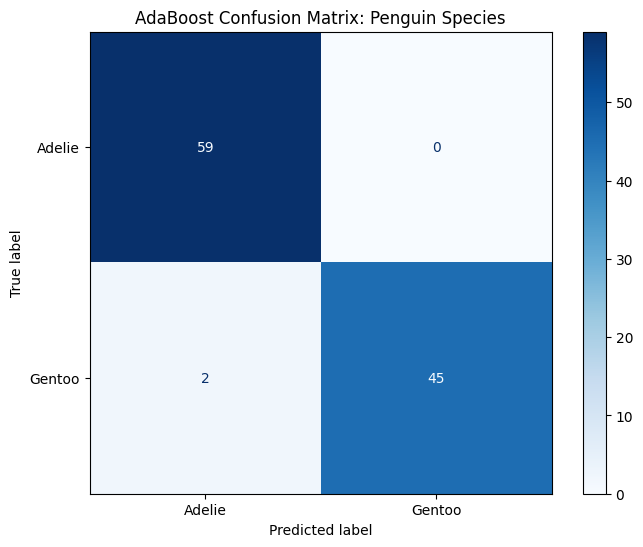

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the confusion matrix for AdaBoost
cm = confusion_matrix(y_test, ada_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Adelie', 'Gentoo'])

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap="Blues", values_format='d', ax=ax)
plt.title("AdaBoost Confusion Matrix: Penguin Species")
plt.show()

And Gradient Boosting (Regression):

Instead of weights, Gradient Boosting fits new models to the residual errors of the previous models. We will simulate a non-linear quadratic relationship to show this progression.

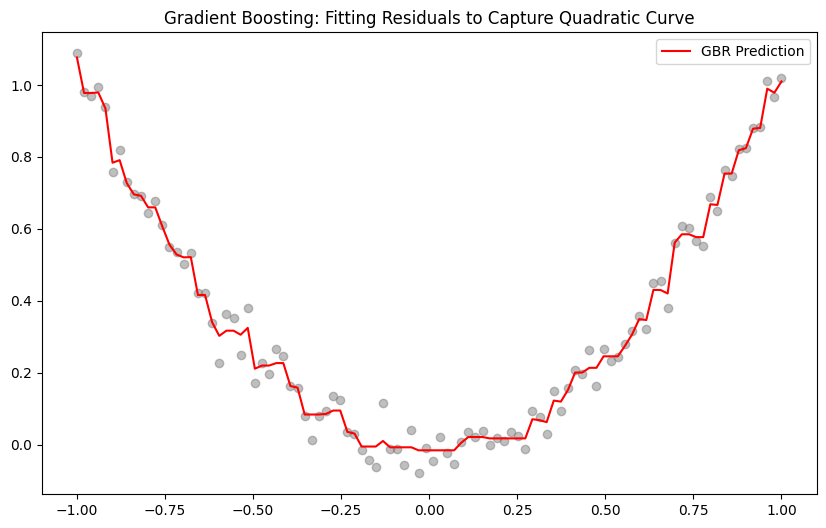

In [12]:
# Generate quadratic data
np.random.seed(0)
X_reg = np.linspace(-1, 1, 100).reshape(-1, 1)
y_reg = (X_reg**2).ravel() + np.random.normal(0, 0.05, 100)

# Manually showing the "Sequential" fit
tree_reg1 = DecisionTreeRegressor(max_depth=2)
tree_reg1.fit(X_reg, y_reg)
# Fit to residuals
res2 = y_reg - tree_reg1.predict(X_reg)
tree_reg2 = DecisionTreeRegressor(max_depth=2)
tree_reg2.fit(X_reg, res2)

# Final Gradient Boosting Regressor
gb_reg = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=2)
gb_reg.fit(X_reg, y_reg)

# Plotting the result
plt.figure(figsize=(10, 6))
plt.scatter(X_reg, y_reg, color='gray', alpha=0.5)
plt.plot(X_reg, gb_reg.predict(X_reg), color='red', label='GBR Prediction')
plt.title("Gradient Boosting: Fitting Residuals to Capture Quadratic Curve")
plt.legend()
plt.show()


Through this notebook, we've demonstrated that ensemble methods like Bagging and Random Forests effectively reduce model variance. Meanwhile, Boosting techniques like AdaBoost and Gradient Boosting iteratively refine predictions to handle complex, non-linear patterns. The choice between them often involves a tradeoff between the stability of Random Forests and the precision of Boosting models.

*most code structure taken from lecture uploads*